Loaded 10324 triples

Top entities by raw frequency:
                             entity  raw_frequency  doc_frequency  mentions_per_paper
                         solubility            690            147                4.69
             water holding capacity            435            112                3.88
                    ultrasonication            359             21               17.10
                   foaming capacity            266             84                3.17
                      pH adjustment            255             33                7.73
               oil holding capacity            251             69                3.64
high hydrostatic pressure treatment            249              6               41.50
         emulsifying activity index            220             63                3.49
                soy protein isolate            194             20                9.70
             surface hydrophobicity            194             61                3.18



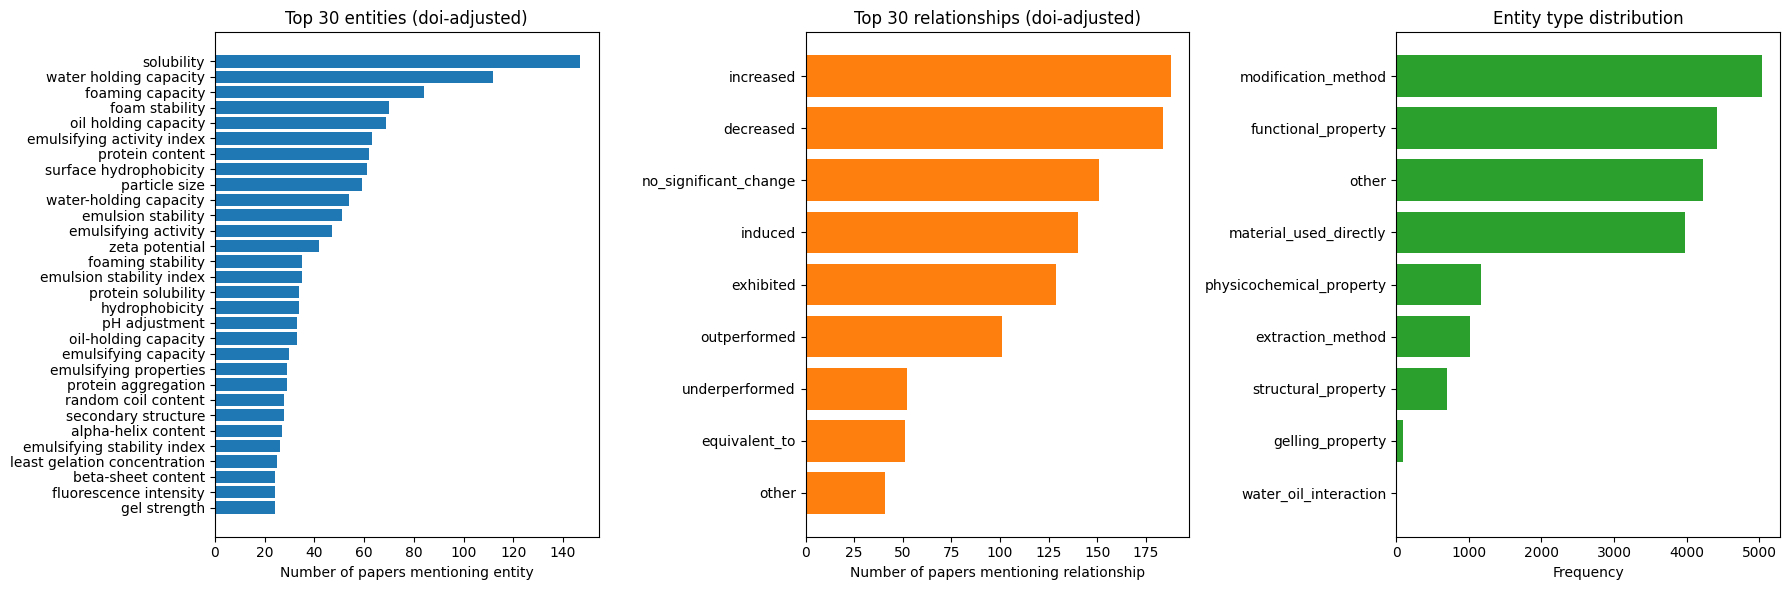


Saved plot to frequency_analysis.png
Saved frequency tables to frequency_analysis.xlsx


In [1]:
"""
Entity, relationship, and entity-type frequency analysis for the
extracted triple knowledge graph.

Mirrors the PlantConnectome analysis (Fig. 3C/3D): counts which
entities and relationships occur most often, and checks whether the
entity type distribution matches what the literature filtering
criteria would predict.

Designed for Jupyter/Colab execution. No __main__ guard.
"""

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------
TRIPLES_PATH = "phase2_terra_full_triples_categorized.xlsx"
SOURCE_COL = "source"
TARGET_COL = "target"
SOURCE_TYPE_COL = "source_type"
TARGET_TYPE_COL = "target_type"
INTERACTION_COL = "interaction"
DOI_COL = "doi"

TOP_N = 30
OUTPUT_XLSX = "frequency_analysis.xlsx"
OUTPUT_PLOT = "frequency_analysis.png"


# ---------------------------------------------------------------
# LOAD
# ---------------------------------------------------------------
def load_triples(path):
    if path.endswith(".parquet"):
        return pd.read_parquet(path)
    elif path.endswith(".xlsx"):
        return pd.read_excel(path)
    elif path.endswith(".csv"):
        return pd.read_csv(path)
    else:
        raise ValueError(f"Unsupported file type: {path}")


df = load_triples(TRIPLES_PATH)
print(f"Loaded {len(df)} triples")

# ---------------------------------------------------------------
# ENTITY FREQUENCY: raw triple count AND doi-adjusted document
# frequency (unique papers mentioning the entity at least once).
# Raw count can be inflated by a small number of papers that mention
# the same entity repeatedly, e.g. one paper contributing 15 separate
# solubility triples. Document frequency avoids that inflation.
# ---------------------------------------------------------------
source_long = df[[SOURCE_COL, DOI_COL]].rename(columns={SOURCE_COL: "entity"})
target_long = df[[TARGET_COL, DOI_COL]].rename(columns={TARGET_COL: "entity"})
entity_long = pd.concat([source_long, target_long])
entity_long["entity"] = entity_long["entity"].astype(str).str.strip()

raw_freq = entity_long["entity"].value_counts().reset_index()
raw_freq.columns = ["entity", "raw_frequency"]

doc_freq = entity_long.groupby("entity")[DOI_COL].nunique().reset_index()
doc_freq.columns = ["entity", "doc_frequency"]

entity_freq = raw_freq.merge(doc_freq, on="entity")
entity_freq["mentions_per_paper"] = (entity_freq["raw_frequency"] / entity_freq["doc_frequency"]).round(2)
entity_freq = entity_freq.sort_values("doc_frequency", ascending=False).reset_index(drop=True)

print("\nTop entities by raw frequency:")
print(entity_freq.sort_values("raw_frequency", ascending=False).head(10).to_string(index=False))

print("\nTop entities by document frequency (doi-adjusted):")
print(entity_freq.head(10).to_string(index=False))

print("\nHighest mentions-per-paper (potential redundancy/chunking artifact, min 5 papers):")
print(entity_freq[entity_freq["doc_frequency"] >= 5]
      .sort_values("mentions_per_paper", ascending=False).head(10).to_string(index=False))

# ---------------------------------------------------------------
# RELATIONSHIP (interaction) FREQUENCY: raw AND doi-adjusted
# ---------------------------------------------------------------
interaction_long = df[[INTERACTION_COL, DOI_COL]].copy()
interaction_long[INTERACTION_COL] = interaction_long[INTERACTION_COL].astype(str).str.strip()

raw_int_freq = interaction_long[INTERACTION_COL].value_counts().reset_index()
raw_int_freq.columns = ["interaction", "raw_frequency"]

doc_int_freq = interaction_long.groupby(INTERACTION_COL)[DOI_COL].nunique().reset_index()
doc_int_freq.columns = ["interaction", "doc_frequency"]

interaction_freq = raw_int_freq.merge(doc_int_freq, on="interaction")
interaction_freq["mentions_per_paper"] = (interaction_freq["raw_frequency"] / interaction_freq["doc_frequency"]).round(2)
interaction_freq = interaction_freq.sort_values("doc_frequency", ascending=False).reset_index(drop=True)

print("\nTop relationships by document frequency (doi-adjusted):")
print(interaction_freq.head(10).to_string(index=False))

# ---------------------------------------------------------------
# ENTITY TYPE DISTRIBUTION (source_type and target_type combined)
# ---------------------------------------------------------------
entity_types = pd.concat([
    df[SOURCE_TYPE_COL].astype(str).str.strip(),
    df[TARGET_TYPE_COL].astype(str).str.strip(),
])
type_freq = entity_types.value_counts().reset_index()
type_freq.columns = ["entity_type", "frequency"]
type_freq["pct_of_total"] = (type_freq["frequency"] / type_freq["frequency"].sum() * 100).round(2)

print("\nEntity type distribution:")
print(type_freq.to_string(index=False))

# ---------------------------------------------------------------
# TYPE BREAKDOWN SPLIT BY SOURCE VS TARGET (source_type and
# target_type often carry different roles, e.g. modification_method
# tends to sit on source, functional_property tends to sit on target)
# ---------------------------------------------------------------
source_type_freq = df[SOURCE_TYPE_COL].astype(str).str.strip().value_counts().reset_index()
source_type_freq.columns = ["source_type", "frequency"]

target_type_freq = df[TARGET_TYPE_COL].astype(str).str.strip().value_counts().reset_index()
target_type_freq.columns = ["target_type", "frequency"]

# ---------------------------------------------------------------
# PLOTS
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

top_entities = entity_freq.head(TOP_N).iloc[::-1]
axes[0].barh(top_entities["entity"], top_entities["doc_frequency"], color="tab:blue")
axes[0].set_title(f"Top {TOP_N} entities (doi-adjusted)")
axes[0].set_xlabel("Number of papers mentioning entity")

top_interactions = interaction_freq.head(TOP_N).iloc[::-1]
axes[1].barh(top_interactions["interaction"], top_interactions["doc_frequency"], color="tab:orange")
axes[1].set_title(f"Top {TOP_N} relationships (doi-adjusted)")
axes[1].set_xlabel("Number of papers mentioning relationship")

axes[2].barh(type_freq["entity_type"].iloc[::-1], type_freq["frequency"].iloc[::-1], color="tab:green")
axes[2].set_title("Entity type distribution")
axes[2].set_xlabel("Frequency")

plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=200)
plt.show()
print(f"\nSaved plot to {OUTPUT_PLOT}")

# ---------------------------------------------------------------
# SAVE WORKBOOK
# ---------------------------------------------------------------
with pd.ExcelWriter(OUTPUT_XLSX) as writer:
    entity_freq.to_excel(writer, sheet_name="entity_frequency", index=False)
    interaction_freq.to_excel(writer, sheet_name="relationship_frequency", index=False)
    type_freq.to_excel(writer, sheet_name="entity_type_distribution", index=False)
    source_type_freq.to_excel(writer, sheet_name="source_type_only", index=False)
    target_type_freq.to_excel(writer, sheet_name="target_type_only", index=False)

print(f"Saved frequency tables to {OUTPUT_XLSX}")